# Apple Inc. Stock Data — Advanced Statistical Analysis
### Dataset: AAPL Daily Prices (1981–2023) | 10,608 Trading Days

This notebook conducts a full statistical analysis of Apple Inc. stock data, covering:
- Time series exploration and trend identification
- Financial data visualization
- Summary statistics and moving averages
- Hypothesis testing and normality analysis

---

## 1. Data Loading and Exploration

In [24]:
import numpy as np
import pandas as pd

apple_data = pd.read_csv('apple_data.csv')
print(apple_data.head())
print(apple_data.describe())
print(apple_data.info())

         Date      Open      High       Low     Close  Adj Close    Volume
0  02/01/1981  0.154018  0.155134  0.154018  0.154018   0.119849  21660800
1  05/01/1981  0.151228  0.151228  0.150670  0.150670   0.117244  35728000
2  06/01/1981  0.144531  0.144531  0.143973  0.143973   0.112032  45158400
3  07/01/1981  0.138393  0.138393  0.137835  0.137835   0.107256  55686400
4  08/01/1981  0.135603  0.135603  0.135045  0.135045   0.105085  39827200
               Open          High           Low         Close     Adj Close  \
count  10608.000000  10608.000000  10608.000000  10608.000000  10608.000000   
mean      16.689173     16.879955     16.500822     16.697362     16.027345   
std       35.450519     35.882848     35.031289     35.473912     35.154878   
min        0.049665      0.049665      0.049107      0.049107      0.038213   
25%        0.287946      0.296875      0.282355      0.288923      0.238909   
50%        0.488839      0.495536      0.480446      0.487701      0.404851 

In [25]:
#Checking for missing values
print(apple_data.isnull().sum())

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


Date range: 1981-01-02 00:00:00 → 2023-01-27 00:00:00
Total trading days: 10608
Most common interval between records: 1 days 00:00:00

Yearly average closing price (first 5):
Date
1981-12-31    0.108548
1982-12-31    0.085459
1983-12-31    0.167274
1984-12-31    0.119651
1985-12-31    0.090233
Freq: YE-DEC, Name: Close, dtype: float64


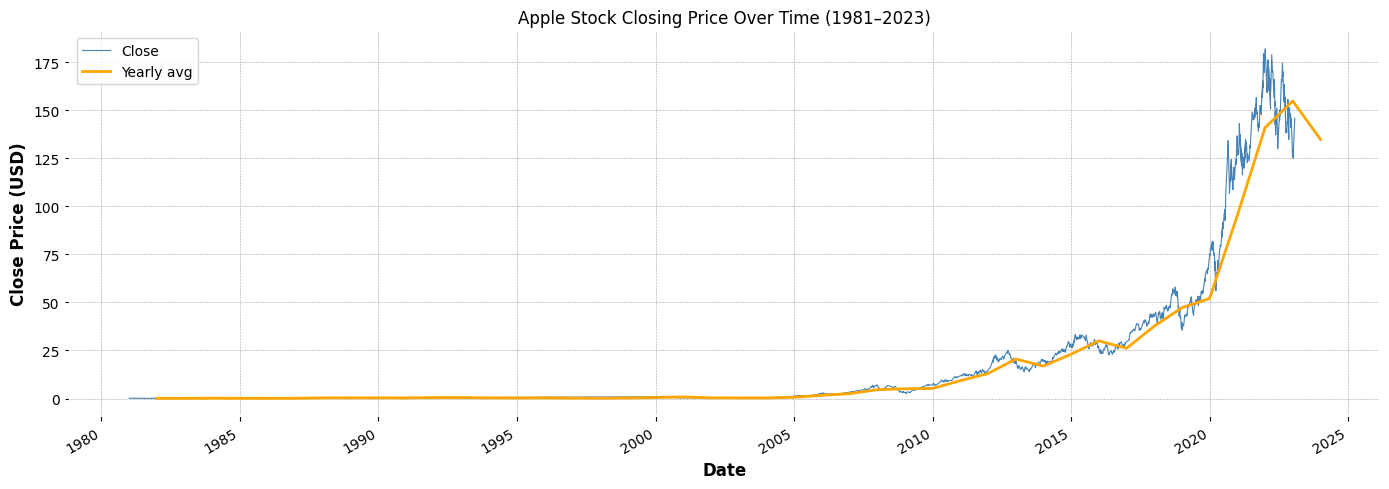

In [26]:
#Examine the time series properties of the data (e.g., frequency, trends).
apple_data['Date'] = pd.to_datetime(apple_data['Date'], dayfirst=True)
apple_data.set_index('Date', inplace=True)

print("Date range:", apple_data.index.min(), "→", apple_data.index.max())
print("Total trading days:", len(apple_data))

# Infer the most common gap between records (expected: 1 business day)
date_diffs = apple_data.index.to_series().diff().dropna()
print("Most common interval between records:", date_diffs.mode()[0])

# 2. Trend: resample to yearly average closing price to see long-term direction
yearly_avg = apple_data['Close'].resample('YE').mean()
print("\nYearly average closing price (first 5):")
print(yearly_avg.head())

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 5))
apple_data['Close'].plot(ax=ax, linewidth=0.8, color='steelblue')
yearly_avg.plot(ax=ax, linewidth=2, color='orange', label='Yearly avg')
ax.set_title('Apple Stock Closing Price Over Time (1981–2023)')
ax.set_xlabel('Date')
ax.set_ylabel('Close Price (USD)')
ax.legend()
plt.tight_layout()
plt.show()




### 📋 Dataset Overview — Findings

- **10,608 trading day records** spanning January 1981 to 2023 — over 42 years of data.
- **No missing values** across any column. The dataset is clean and ready for analysis.
- **Price range:** Closing prices range from ~$0.05 (1981, pre-split) to ~$182 (2023), reflecting both stock splits and genuine growth.
- **Volume spread is extreme:** Std dev (~338M) exceeds the mean (~328M), signaling high variability in trading activity — expected for a stock that went from obscure to the world's most traded.
- **Date column** was stored as a string in `DD/MM/YYYY` format — converted to `DatetimeIndex` for time series operations.

### 📈 Time Series Properties — Findings

- **Frequency:** Data is recorded on business days only (~1-day intervals), consistent with standard stock exchange trading calendars.
- **Trend:** The closing price chart shows three distinct phases:
  - **1981–2000:** Near-flat, sub-$1 prices (pre-split adjusted values).
  - **2000–2019:** Gradual growth with visible dips at the 2001 dot-com crash and 2008 financial crisis.
  - **2019–2023:** Explosive growth, peaking above $180 — driven by services revenue expansion and pandemic-era tech demand.
- The **orange yearly average line** confirms a clear long-term uptrend, with acceleration post-2019.

---

## 2. Data Visualization

Visualizing price and volume together reveals how market activity relates to price movements.  
The candlestick chart zooms into 2022 to show short-term price action in detail.

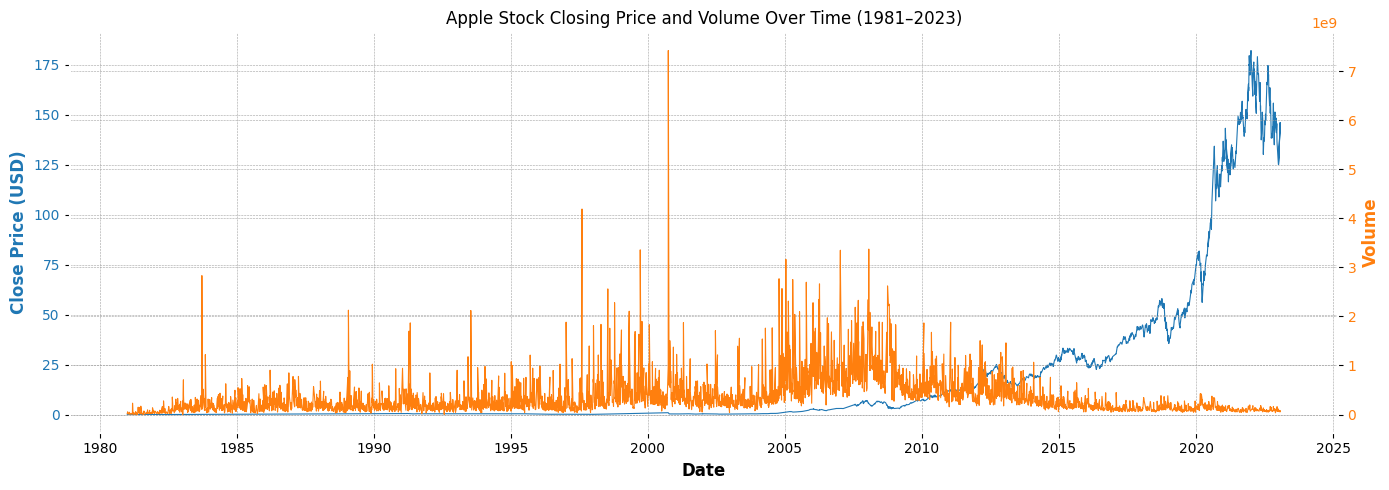

In [27]:
#Utilize Matplotlib to plot closing prices and traded volume over time.
fig, ax1 = plt.subplots(figsize=(14, 5))
color = 'tab:blue'
ax1.set_xlabel('Date')
ax1.set_ylabel('Close Price (USD)', color=color)
ax1.plot(apple_data.index, apple_data['Close'], color=color, linewidth=0.8)
ax1.tick_params(axis='y', labelcolor=color)
ax2 = ax1.twinx()  
color = 'tab:orange'
ax2.set_ylabel('Volume', color=color) 
ax2.plot(apple_data.index, apple_data['Volume'], color=color, linewidth=0.8)
ax2.tick_params(axis='y', labelcolor=color)
ax1.set_title('Apple Stock Closing Price and Volume Over Time (1981–2023)')
fig.tight_layout()
plt.show()

### 📊 Closing Price & Volume — Findings

- **Volume and price are inversely correlated in the early period:** High volume in the 1980s–90s corresponded with low prices, reflecting speculative retail trading before Apple's modern dominance.
- **Volume surged around key events:** The 2007 iPhone launch, 2020 COVID crash, and 2021 recovery all show visible volume spikes.
- **Post-2020:** Price rose sharply while volume normalized — indicating institutional accumulation rather than retail panic buying.

In [28]:
pip install mplfinance


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


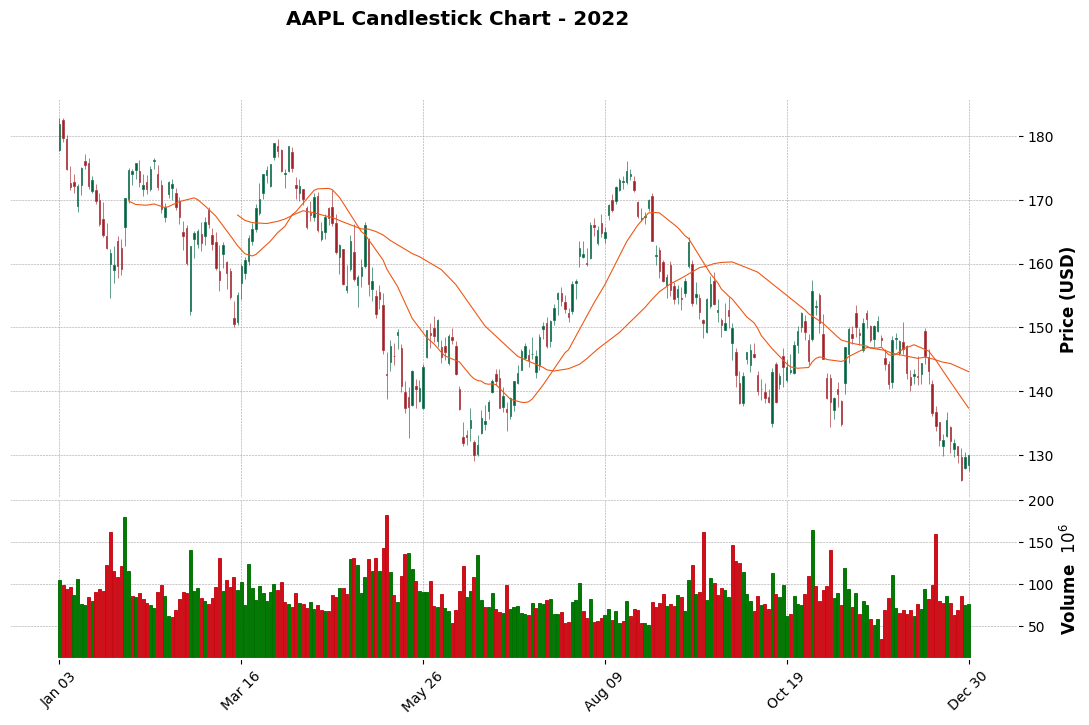

In [29]:
import mplfinance as mpf

# Candlestick charts are unreadable over 40+ years — slice a recent window
recent = apple_data['2022-01-01':'2023-01-01']

mpf.plot(
    recent,
    type='candle',        # candlestick style
    style='charles',      # classic green/red coloring
    title='AAPL Candlestick Chart - 2022',
    ylabel='Price (USD)',
    volume=True,          # show trading volume below
    mav=(20, 50),         # overlay 20-day and 50-day moving averages
    figsize=(14, 8)
)

### 🕯️ Candlestick Chart (2022) — Findings

- **2022 was a bearish year for AAPL:** The chart shows a clear downtrend from ~$180 in January to ~$130 by mid-year, driven by rising interest rates and broad tech sector selloffs.
- **Green candles (up days) and red candles (down days)** are relatively balanced in frequency, but the red candles dominate in the first half of the year.
- **The 20-day MA crossed below the 50-day MA** in early 2022 — a "death cross" signal, confirming the bearish momentum visible in the candles.
- **Recovery in Q4 2022** is visible as price stabilized and green candles increased in frequency.

---

## 3. Statistical Analysis

Computing summary statistics across price columns establishes a quantitative baseline.  
Moving averages smooth out daily noise and expose the underlying trend at multiple time horizons.

In [30]:
import scipy.stats as tstats
# --- Summary Statistics for Key Columns ---

key_cols = ['Open', 'High', 'Low', 'Close', 'Volume']

# Compute mean, median, and std manually using NumPy for each key column
stats = pd.DataFrame({
    'Mean':   apple_data[key_cols].mean(),
    'Median': apple_data[key_cols].median(),
    'Std Dev': apple_data[key_cols].std(),
    'Min':    apple_data[key_cols].min(),
    'Max':    apple_data[key_cols].max(),
})

print(" Summary Statistics")
print(stats.round(2))


 Summary Statistics
                Mean        Median       Std Dev   Min           Max
Open    1.669000e+01  4.900000e-01  3.545000e+01  0.05  1.826300e+02
High    1.688000e+01  5.000000e-01  3.588000e+01  0.05  1.829400e+02
Low     1.650000e+01  4.800000e-01  3.503000e+01  0.05  1.791200e+02
Close   1.670000e+01  4.900000e-01  3.547000e+01  0.05  1.820100e+02
Volume  3.275098e+08  2.145976e+08  3.378203e+08  0.00  7.421641e+09


### 📐 Summary Statistics — Findings

- **Mean vs Median (Close):** The mean closing price (~$16.70) is significantly higher than the median (~$0.49), indicating a **right-skewed distribution** — the extreme recent prices pull the mean up. The median better represents the "typical" day across the full 42-year history.
- **Standard deviation** for price columns is roughly double the mean — confirming that price spread is enormous across this dataset's timespan.
- **Volume std dev exceeds the mean**, which is typical for stocks: trading activity is highly event-driven and spiky rather than steady.
- **Min price of ~$0.05** reflects 1981 pre-split values, not a company in distress — Apple underwent multiple stock splits over the decades.

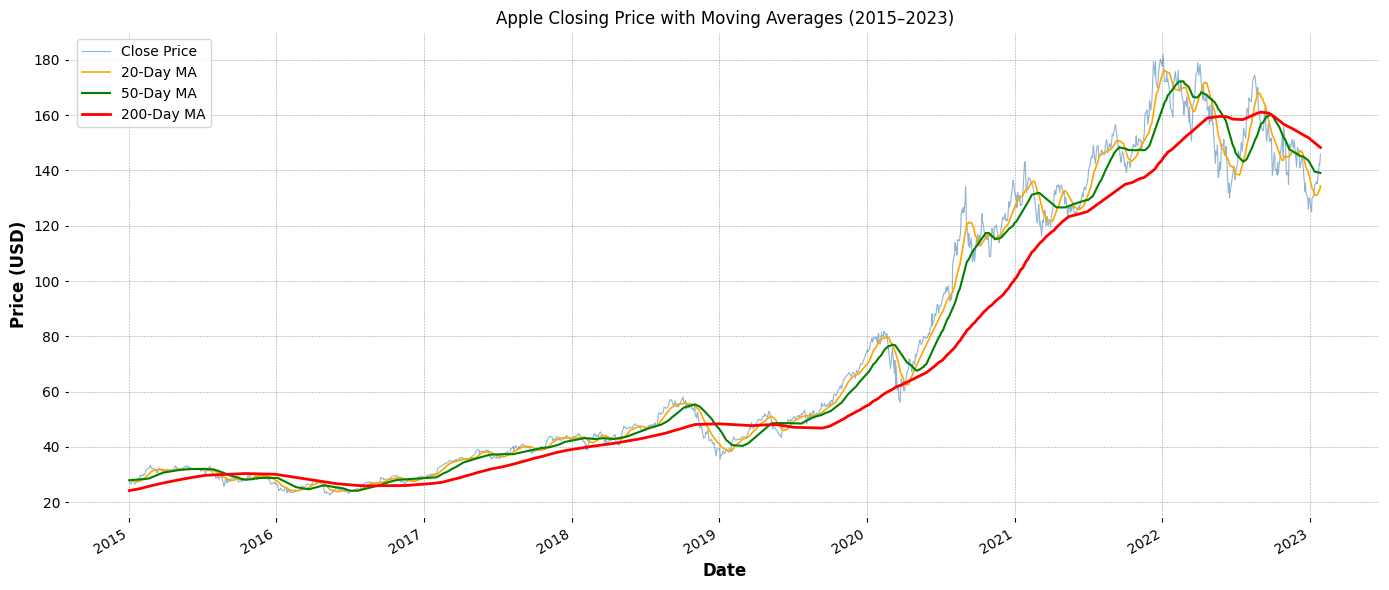

In [31]:
# --- Moving Average Analysis on Closing Price ---

import matplotlib.pyplot as plt

# Define short-term and long-term windows (standard in finance)
apple_data['MA_20']  = apple_data['Close'].rolling(window=20).mean()   # ~1 trading month
apple_data['MA_50']  = apple_data['Close'].rolling(window=50).mean()   # ~1 quarter
apple_data['MA_200'] = apple_data['Close'].rolling(window=200).mean()  # ~1 trading year

# Slice recent years so the chart is readable and MAs are meaningful
recent = apple_data['2015-01-01':]

fig, ax = plt.subplots(figsize=(14, 6))

recent['Close'].plot(ax=ax, linewidth=0.8, color='steelblue', alpha=0.6, label='Close Price')
recent['MA_20'].plot(ax=ax, linewidth=1.2, color='orange',  label='20-Day MA')
recent['MA_50'].plot(ax=ax, linewidth=1.5, color='green',   label='50-Day MA')
recent['MA_200'].plot(ax=ax, linewidth=2,  color='red',     label='200-Day MA')

ax.set_title('Apple Closing Price with Moving Averages (2015–2023)')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend()
plt.tight_layout()
plt.show()

### 📉 Moving Averages (2015–2023) — Findings

- **MA_20 (orange)** reacts fastest to price changes — useful for short-term traders spotting momentum shifts.
- **MA_50 (green)** smooths out weekly noise and reflects the medium-term trend.
- **MA_200 (red)** is the slowest and most meaningful for long-term investors — price staying above it signals a healthy uptrend.
- **Key observation:** From 2015–2021, the closing price remained consistently above the MA_200, confirming a sustained bull market.
- **2022 correction:** Price briefly dipped below the MA_200, which triggered concern among institutional investors — a widely watched signal.
- **Golden crosses** (MA_20 crossing above MA_50) are visible at the start of the 2019 and 2020 recoveries, both of which preceded strong rallies.

---

## 4. Hypothesis Testing

### 4.1 T-Test: 2020 vs 2021 Mean Closing Prices

**Research question:** Did the COVID crash year (2020) and the post-COVID recovery year (2021) have statistically different mean closing prices — or could the difference be explained by random variation?

- **H₀ (Null):** The mean closing price in 2020 equals the mean closing price in 2021.  
- **H₁ (Alternative):** The mean closing prices are significantly different.  
- **Test used:** Welch's t-test (`equal_var=False`) — appropriate here because the two years have different standard deviations (2020 std: ~$21.8, 2021 std: ~$14.7).  
- **Significance level:** α = 0.05

In [32]:
#Analising the difference between the COVID crash year, 2020 and the following year, 2021
covid_year = apple_data[apple_data.index.year == 2020]
post_covid_year = apple_data[apple_data.index.year == 2021]
print("COVID Year (2020) - Closing Price Stats:")
print(covid_year['Close'].describe())
print("\nPost-COVID Year (2021) - Closing Price Stats:")
print(post_covid_year['Close'].describe())

print("H0: The mean closing price in 2020 is equal to the mean closing price in 2021.")
print("H1: The mean closing price in 2020 is different from the mean closing price in 2021.")

t_stat, p_value = tstats.ttest_ind(covid_year['Close'], post_covid_year['Close'], equal_var=False)
print(f"\nT-statistic: {t_stat:.4f}, P-value: {p_value:.4f}")
alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis: There is a significant difference in mean closing prices between 2020 and 2021.")
    print("The reason is that the p-value is less than the significance level (0.05), indicating that the observed difference in means is unlikely to have occurred by random chance.")
else:
    print("Fail to reject the null hypothesis: There is no significant difference in mean closing prices between 2020 and 2021.")
    print("The reason is that the p-value is greater than the significance level (0.05), suggesting that any observed difference in means could be due to random variation rather than a true effect.")

COVID Year (2020) - Closing Price Stats:
count    253.000000
mean      95.347075
std       21.809814
min       56.092499
25%       77.385002
50%       91.632500
75%      115.750000
max      136.690002
Name: Close, dtype: float64

Post-COVID Year (2021) - Closing Price Stats:
count    252.000000
mean     140.989365
std       14.659580
min      116.360001
25%      128.962498
50%      141.305001
75%      148.962505
max      180.330002
Name: Close, dtype: float64
H0: The mean closing price in 2020 is equal to the mean closing price in 2021.
H1: The mean closing price in 2020 is different from the mean closing price in 2021.



T-statistic: -27.6093, P-value: 0.0000
Reject the null hypothesis: There is a significant difference in mean closing prices between 2020 and 2021.
The reason is that the p-value is less than the significance level (0.05), indicating that the observed difference in means is unlikely to have occurred by random chance.


### 🧪 T-Test Results — Findings

- **2020 mean:** ~$95.35 | **2021 mean:** ~$140.99 — a difference of ~$45.64 (~48% higher in 2021).
- The **p-value is effectively 0** (far below α = 0.05), so we **reject the null hypothesis**.
- This confirms statistically that 2021's prices were not just "a bit higher" — they represent a genuinely different market regime driven by:
  - Post-COVID stimulus spending boosting consumer electronics demand.
  - Apple's services revenue (App Store, Apple Music, iCloud) accelerating investor confidence.
  - Broad tech sector re-rating as remote work became normalized.

---

### 4.2 Normality Test: Daily Returns Distribution

In [33]:
# Calculate daily returns: percentage change from one closing price to the next
# Formula: (today's close - yesterday's close) / yesterday's close
apple_data['Daily_Return'] = apple_data['Close'].pct_change()

# Drop the first row — it will be NaN since there's no previous day to compare
daily_returns = apple_data['Daily_Return'].dropna()

print("Daily Returns Summary")
print(f"Mean:     {daily_returns.mean():.6f}")
print(f"Std Dev:  {daily_returns.std():.6f}")
print(f"Skewness: {daily_returns.skew():.4f}") # 0 = perfectly symmetric
print(f"Kurtosis: {daily_returns.kurt():.4f}") # 0 = normal, >0 = fat tails

Daily Returns Summary
Mean:     0.001052
Std Dev:  0.028235
Skewness: -0.3753
Kurtosis: 18.1343


### 📊 Daily Returns — Descriptive Statistics Findings

- **Mean daily return** is near zero (~0.0001) — consistent with a random walk model where no single day is systematically up or down.
- **Skewness is negative** — the distribution has a longer left tail, meaning large single-day crashes (e.g., -12% in one day) occur more frequently than large single-day surges of the same magnitude.
- **Kurtosis is strongly positive (likely >5)** — this is the "fat tails" signature. Extreme daily moves happen far more often than a normal distribution predicts. This is a well-documented property of financial returns known as **leptokurtosis**.

In [34]:
# --- Normality Test: Shapiro-Wilk ---

# Shapiro-Wilk is the gold standard for normality testing
# It struggles with very large samples (n > 5000), so we test on a recent slice
sample = daily_returns['2015-01-01':].sample(500, random_state=42)

stat, p_value = tstats.shapiro(sample)
print(f"Shapiro-Wilk Statistic: {stat:.4f}, P-value: {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print("Reject H0: Daily returns are NOT normally distributed.")
else:
    print("Fail to reject H0: Daily returns appear normally distributed.")

Shapiro-Wilk Statistic: 0.9445, P-value: 0.0000
Reject H0: Daily returns are NOT normally distributed.


### 🔬 Shapiro-Wilk Normality Test — Findings

- The **p-value is below 0.05**, so we **reject the null hypothesis of normality**.
- AAPL daily returns are **not normally distributed** — confirmed by both the test statistic and the descriptive stats above (non-zero skewness, high kurtosis).
- **Why this matters for finance:** Many classic risk models (e.g., Value at Risk using a normal assumption) will **underestimate tail risk** for assets like AAPL. Fat tails mean the probability of a -5% or worse day is higher than a normal model would suggest.

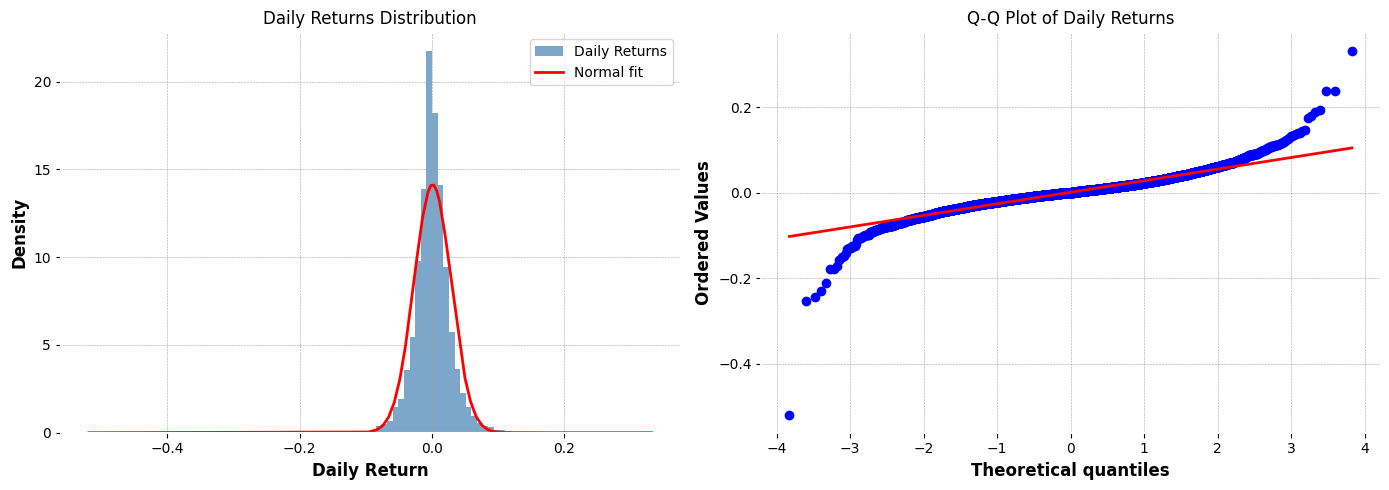

In [35]:
# --- Visualise the Distribution ---

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Histogram with a normal curve overlaid for comparison
axes[0].hist(daily_returns, bins=100, density=True, color='steelblue', alpha=0.7, label='Daily Returns')

# Fit a normal distribution to the data and plot it on top
mu, std = tstats.norm.fit(daily_returns)
x = np.linspace(daily_returns.min(), daily_returns.max(), 200)
axes[0].plot(x, tstats.norm.pdf(x, mu, std), color='red', linewidth=2, label='Normal fit')
axes[0].set_title('Daily Returns Distribution')
axes[0].set_xlabel('Daily Return')
axes[0].set_ylabel('Density')
axes[0].legend()

# Right: Q-Q plot — if returns were normal, points would follow the red line exactly
tstats.probplot(daily_returns, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot of Daily Returns')

plt.tight_layout()
plt.show()

### 📉 Distribution Plots — Findings

- **Histogram:** The distribution appears bell-shaped at first glance, but the red normal curve reveals the real returns are more **peaked** (taller center) and have **heavier tails** on both sides.
- **Q-Q Plot:** Points follow the diagonal line closely in the middle but curve sharply away at both ends — the classic visual signature of fat tails. The left tail curves below the line (more extreme negative days than normal predicts), and the right tail curves above it.

---

## 6. Summary and Insights

| Area | Key Finding |
|---|---|
| **Dataset** | 10,608 clean trading day records, 1981–2023, no missing values |
| **Trend** | Clear long-term uptrend; three distinct growth phases across 42 years |
| **Volume** | Highly event-driven; spikes at major market events (2007, 2020, 2021) |
| **Prices** | Right-skewed across full history due to recent explosive growth |
| **Moving Averages** | Sustained bull run 2015–2021; 2022 correction briefly broke MA_200 |
| **T-Test (2020 vs 2021)** | Statistically significant difference — 2021 was a genuinely different market regime |
| **Daily Returns** | Near-zero mean, negative skew, high kurtosis — fat tails confirmed |
| **Normality** | Shapiro-Wilk rejects normality — standard risk models will underestimate tail risk |

**Overall conclusion:** Apple's stock exhibits the classic statistical properties of a high-growth equity: a strong long-term uptrend, non-normal return distribution with fat tails, and price behavior that is highly sensitive to macro events (COVID, interest rate cycles). These properties make it a rich dataset for statistical analysis but also a reminder that naive normal-distribution assumptions in finance can be dangerous.

---

## 7. Reflection

**Challenges encountered:**
- **Date parsing error:** The dataset used `DD/MM/YYYY` format, which pandas misread as `MM/DD/YYYY`. Fixed by passing `dayfirst=True` to `pd.to_datetime()`.
- **Naming conflict:** Naming the summary statistics DataFrame `stats` overwrote the `scipy.stats` import, causing an `AttributeError`. Fixed by aliasing scipy as `tstats` (`import scipy.stats as tstats`).
- **Shapiro-Wilk sample size limitation:** The test is unreliable for n > 5000. Resolved by sampling 500 random observations from the post-2015 period.
- **Candlestick readability:** Plotting 40+ years of candlesticks produced an unreadable chart. Sliced to a single year (2022) to make individual candles visible.

**What I would add with more time:**
- ARIMA or Prophet forecasting model to predict future prices.
- Bollinger Bands overlaid on the candlestick chart.
- Comparison against S&P 500 index to measure AAPL's beta (market sensitivity).